# 06 — Hyperparameter analysis

**Purpose:** Identify which hyperparameters are associated with predictive
multiplicity *within* each model family across Rashomon sets.

**Approach (family-first, V_m-based):**

1. For each outer seed and each model family, select the within-family
   Rashomon set (top-K by val_brier).
2. Compute model-level *disagreement contribution*
   V_m = mean_x( (P[m,x] − p̄(x))² ) — how much model m deviates from
   its family’s ensemble mean.
3. For each HP, group models by HP value and compute between-group / total
   variance of V_m (“importance ratio”).
4. Aggregate importance across seeds: report mean ± std and rank stability.

**Why per-family?** Hyperparameters are family-specific; mixing families
introduces NaN columns and spurious importance from family proxies.

**Caveat:** All associations reported here are *marginal* (univariate
grouping by one HP at a time), not causal partial dependence.

**Outputs:**
- `thesis_outputs/tables/nb06/hp_importance_per_seed_{dataset}.csv`
- `thesis_outputs/tables/nb06/hp_importance_agg_{dataset}.csv`
- `thesis_outputs/figures/nb06/hp_importance_bar_{dataset}_{family}.pdf`
- `thesis_outputs/figures/nb06/hp_rank_stability_{dataset}_{family}.pdf`
- `thesis_outputs/figures/nb06/hp_marginal_effect_{dataset}_{family}_{hp}.pdf`

## Imports and path setup

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.experiment_runner import _get_run_dirs
from analysis.hp_analysis import (
    select_rashomon_family,
    compute_Vm,
    hp_importance_Vm,
    marginal_Vm_by_hp,
    run_hp_importance_all_seeds,
    aggregate_hp_importance,
)
from analysis.hyperparams import ensure_hp_columns, make_hp_key
from analysis.run_analysis import load_meta, load_P_test, select_rashomon_per_family_k_each

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb06")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## Configuration

In [2]:
DATASETS = ["compas", "german", "adult"]
K = 25        # within-family Rashomon size
K_EACH = 25   # models per family for diversity / HP analysis (select_rashomon_per_family_k_each)
TOP_HP = 10   # max HPs to show in bar plots

## Per-seed, per-family HP importance

For every (dataset, seed, family) triple: select within-family Rashomon,
compute V_m, and compute importance of each HP via between-group variance
of V_m.  Results are saved to CSV.

In [3]:
all_per_seed = []
all_Vm = []

for ds in DATASETS:
    ds_dir = RESULTS_DIR / ds
    if not ds_dir.is_dir() or not _get_run_dirs(ds_dir):
        print(f"Skipping {ds}: no runs found.")
        continue
    df_ps, df_vm = run_hp_importance_all_seeds(ds_dir, ds, K=K)
    if not df_ps.empty:
        all_per_seed.append(df_ps)
    if not df_vm.empty:
        all_Vm.append(df_vm)
    n_seeds = df_ps["seed"].nunique() if not df_ps.empty else 0
    n_fams = df_ps["family"].nunique() if not df_ps.empty else 0
    print(f"{ds}: {n_seeds} seeds × {n_fams} families, {len(df_ps)} importance rows")

df_per_seed = pd.concat(all_per_seed, ignore_index=True) if all_per_seed else pd.DataFrame()
df_Vm_all = pd.concat(all_Vm, ignore_index=True) if all_Vm else pd.DataFrame()

for ds in DATASETS:
    sub = df_per_seed[df_per_seed["dataset"] == ds]
    if not sub.empty:
        out = TABLE_DIR / f"hp_importance_per_seed_{ds}.csv"
        sub.to_csv(out, index=False)
        print(f"Saved: {out}")

compas: 10 seeds × 5 families, 176 importance rows
german: 10 seeds × 5 families, 180 importance rows
adult: 10 seeds × 5 families, 179 importance rows
Saved: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_importance_per_seed_compas.csv
Saved: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_importance_per_seed_german.csv
Saved: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_importance_per_seed_adult.csv


## Per-seed results table

Inspect the per-seed importance DataFrame: each row is one (seed, family, HP)
with its importance ratio, number of unique HP values, and model count.

In [4]:
if not df_per_seed.empty:
    display(
        df_per_seed.sort_values(
            ["dataset", "family", "seed", "ratio_of_sums"],
            ascending=[True, True, True, False],
        ).head(40)
    )
    print(f"\nShape: {df_per_seed.shape}")
    print(f"\nK_actual distribution:")
    print(
        df_per_seed.groupby(["dataset", "family"])["K_actual"]
        .agg(["min", "max", "mean"])
        .round(1)
    )
else:
    print("No per-seed results.")

,hp_name,ratio_of_sums,n_values,n_models,mean_V_m,dataset,seed,family,K_actual
356,n_estimators,0.221484,3,25,0.001461,adult,0,GBM,25
357,learning_rate,0.180003,3,25,0.001461,adult,0,GBM,25
358,max_depth,0.069629,4,25,0.001461,adult,0,GBM,25
359,subsample,0.056705,3,25,0.001461,adult,0,GBM,25
374,learning_rate,0.254500,4,25,0.001306,adult,1,GBM,25
375,max_depth,0.245224,4,25,0.001306,adult,1,GBM,25
376,n_estimators,0.077601,3,25,0.001306,adult,1,GBM,25
377,subsample,0.008670,3,25,0.001306,adult,1,GBM,25
392,n_estimators,0.220439,3,25,0.001474,adult,2,GBM,25
393,learning_rate,0.179385,4,25,0.001474,adult,2,GBM,25



Shape: (535, 9)

K_actual distribution:
                min  max  mean
dataset family                
adult   GBM      25   25  25.0
        LogReg   25   25  25.0
        MLP      25   25  25.0
        RF       25   25  25.0
        kNN      25   25  25.0
compas  GBM      25   25  25.0
        LogReg   25   25  25.0
        MLP      25   25  25.0
        RF       25   25  25.0
        kNN      25   25  25.0
german  GBM      25   25  25.0
        LogReg   25   25  25.0
        MLP      25   25  25.0
        RF       25   25  25.0
        kNN      25   25  25.0


## Aggregated HP importance across seeds

Mean ± std of importance ratio, plus rank stability (frequency of appearing
in top-1 and top-3 across seeds).

In [5]:
df_agg = aggregate_hp_importance(df_per_seed)

if not df_agg.empty:
    for ds in DATASETS:
        sub = df_agg[df_agg["dataset"] == ds]
        if sub.empty:
            continue
        out = TABLE_DIR / f"hp_importance_agg_{ds}.csv"
        sub.to_csv(out, index=False)
        print(f"Saved: {out}")
    display(df_agg.head(40))
else:
    print("No aggregated results.")

Saved: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_importance_agg_compas.csv
Saved: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_importance_agg_german.csv
Saved: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb06\hp_importance_agg_adult.csv


,dataset,family,hp_name,mean_importance,std_importance,n_seeds,mean_V_m,rank_freq_top1,rank_freq_top3
0,adult,GBM,learning_rate,0.246709,0.086559,10,0.001383,0.7,1.0
1,adult,GBM,max_depth,0.116870,0.091055,10,0.001383,0.1,0.9
2,adult,GBM,n_estimators,0.112527,0.096963,10,0.001383,0.2,0.7
3,adult,GBM,subsample,0.043683,0.048021,10,0.001383,0.0,0.4
4,adult,LogReg,C,0.921326,0.069895,10,0.000056,1.0,1.0
5,adult,LogReg,l1_ratio,0.111941,0.059019,10,0.000056,0.0,1.0
6,adult,MLP,learning_rate_init,0.512938,0.179573,10,0.001549,0.8,1.0
7,adult,MLP,hidden_layer_sizes,0.158801,0.116265,10,0.001549,0.2,0.7
8,adult,MLP,alpha,0.138060,0.142318,10,0.001549,0.0,0.6
9,adult,MLP,activation,0.112491,0.068456,10,0.001549,0.0,0.7


## HP importance bar plots (mean ± std across seeds)

For each dataset and family, horizontal bar plot of the top HPs ranked by
mean importance with std error bars.

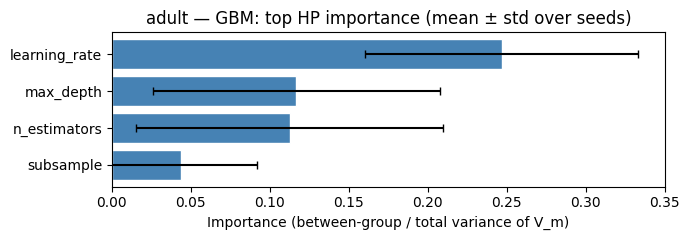

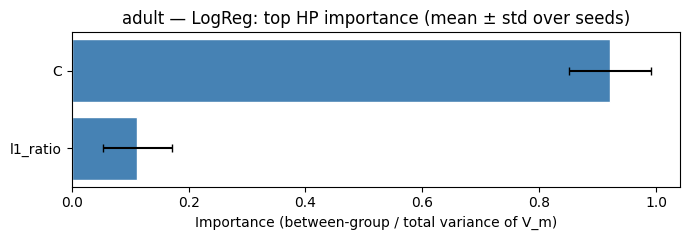

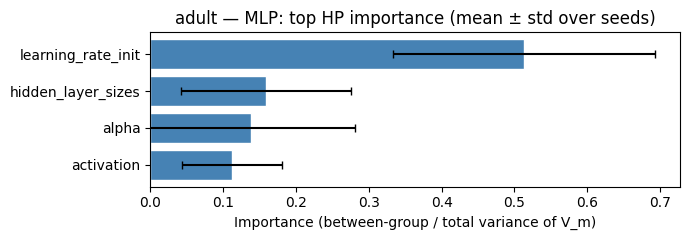

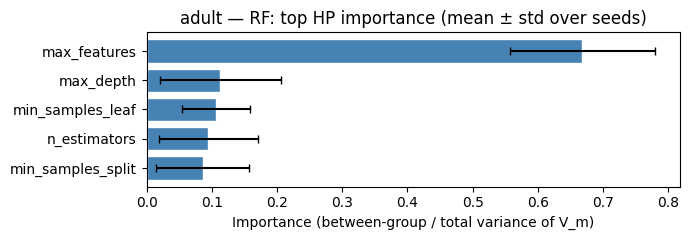

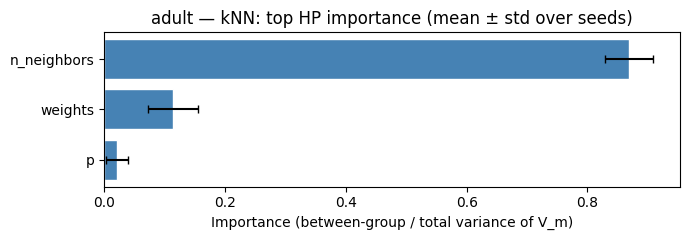

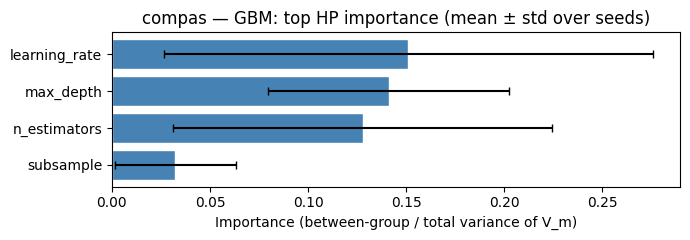

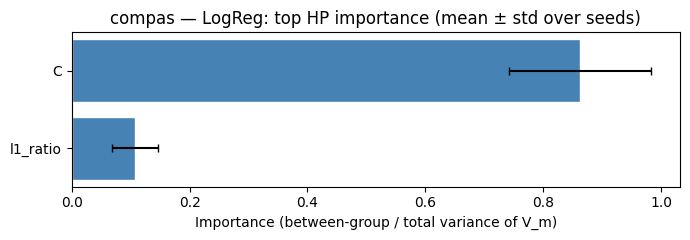

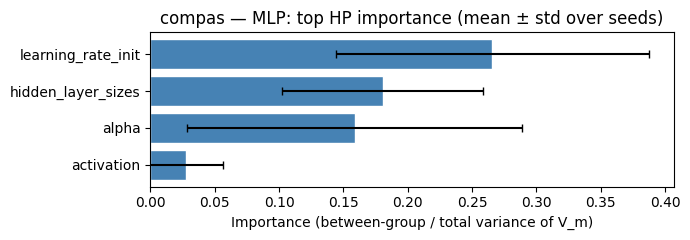

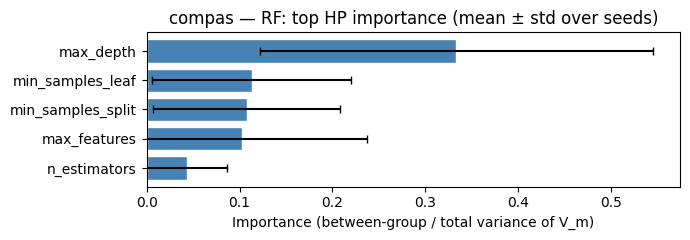

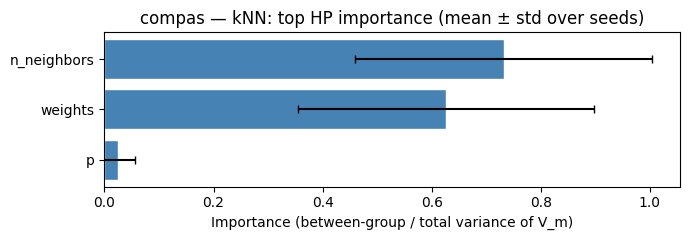

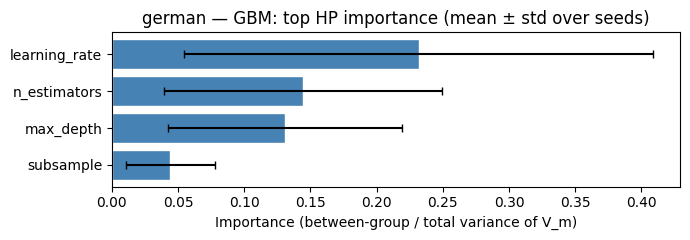

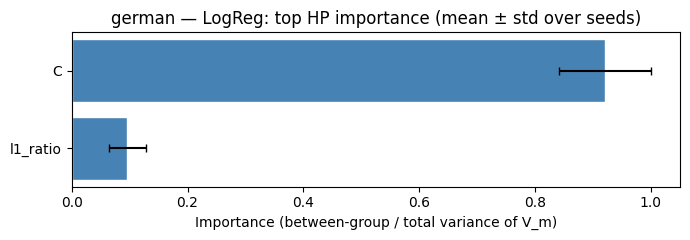

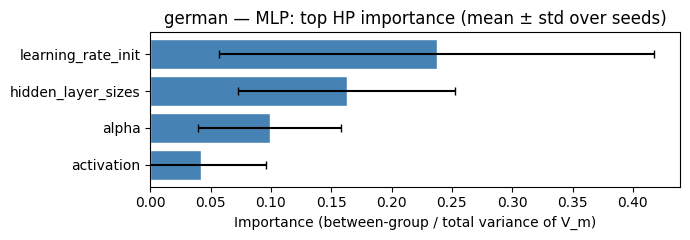

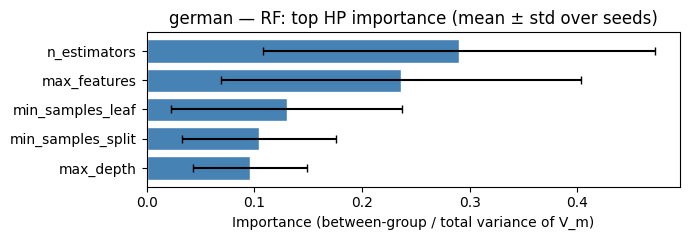

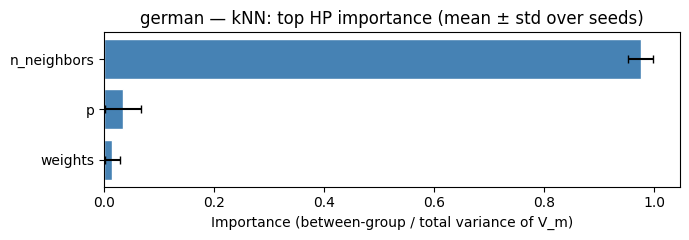

In [6]:
if not df_agg.empty:
    for (ds, fam), grp in df_agg.groupby(["dataset", "family"]):
        top = grp.head(TOP_HP).iloc[::-1]
        if top.empty:
            continue

        fig, ax = plt.subplots(figsize=(7, max(2.5, 0.4 * len(top))))
        ax.barh(
            top["hp_name"],
            top["mean_importance"],
            xerr=top["std_importance"],
            capsize=3,
            color="steelblue",
            edgecolor="white",
        )
        ax.set_xlabel("Importance (between-group / total variance of V_m)")
        ax.set_title(f"{ds} — {fam}: top HP importance (mean ± std over seeds)")
        ax.set_xlim(left=0)
        fig.tight_layout()
        fig.savefig(
            FIG_DIR / f"hp_importance_bar_{ds}_{fam}.pdf", bbox_inches="tight"
        )
        plt.show()

## Rank stability

For the same top HPs, how often does each appear in the top-3 across seeds?
High frequency means the HP is a *robust* driver of within-family multiplicity.

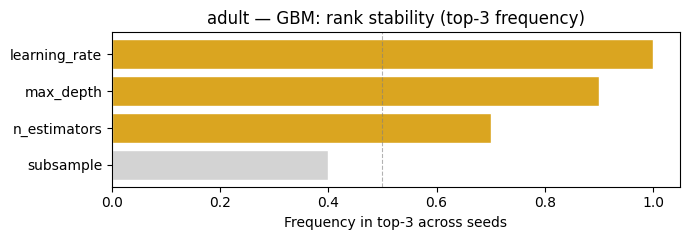

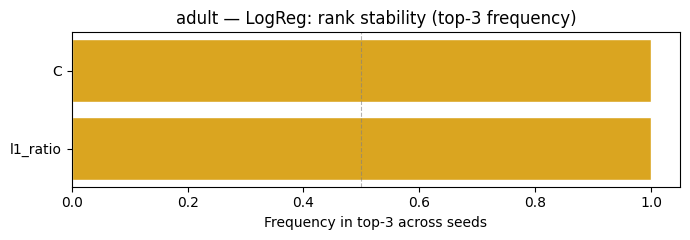

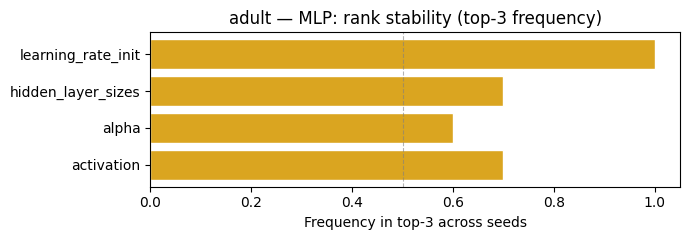

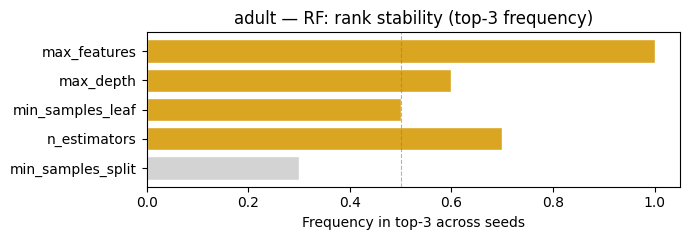

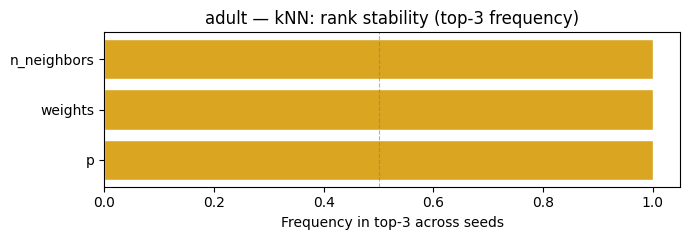

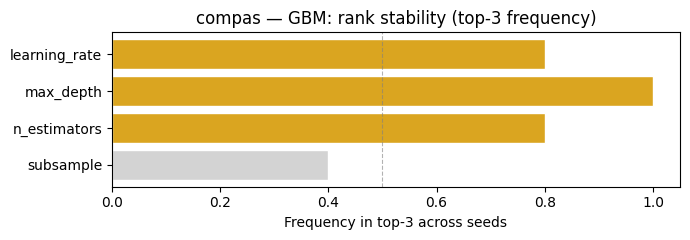

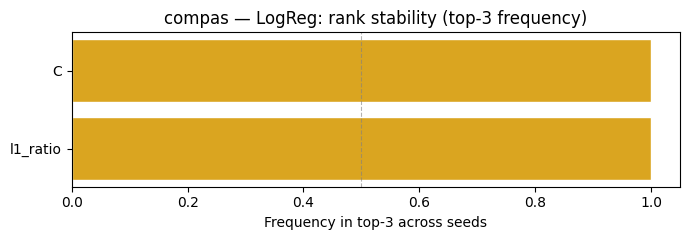

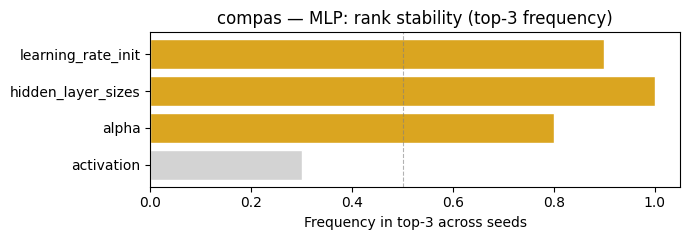

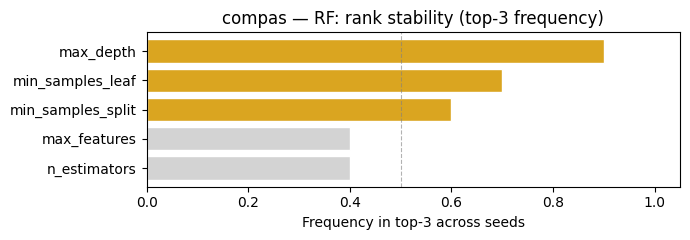

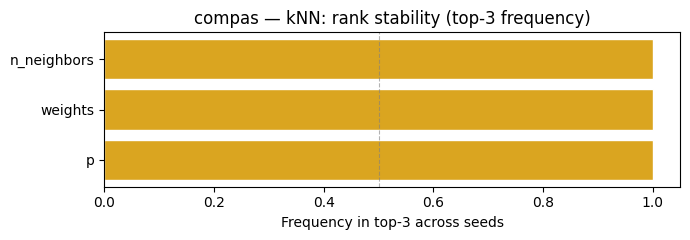

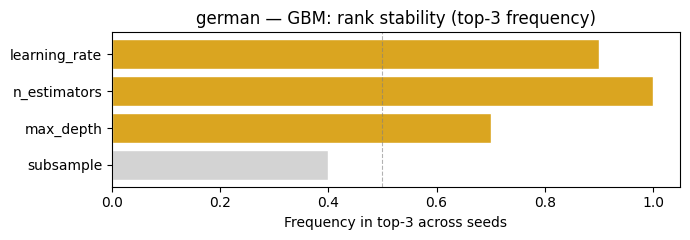

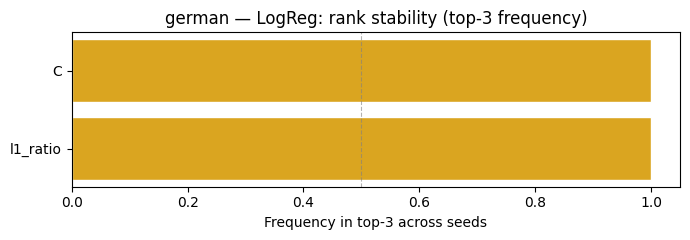

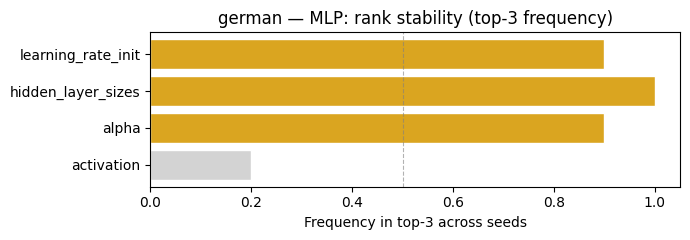

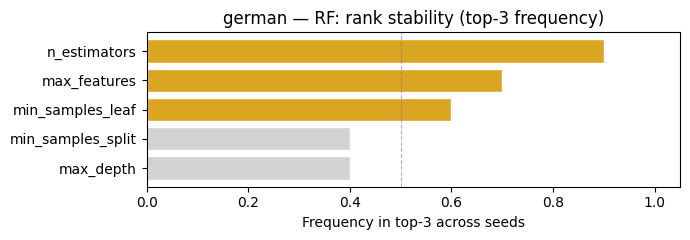

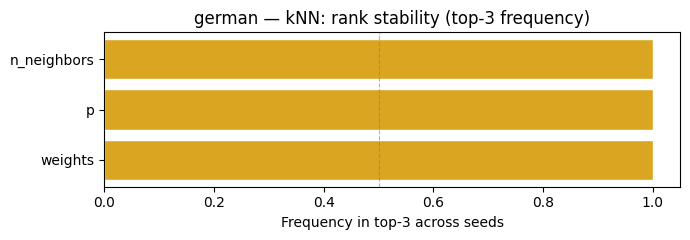

In [7]:
if not df_agg.empty:
    for (ds, fam), grp in df_agg.groupby(["dataset", "family"]):
        top = grp.head(TOP_HP).iloc[::-1]
        if top.empty:
            continue

        fig, ax = plt.subplots(figsize=(7, max(2.5, 0.4 * len(top))))
        colors = [
            "goldenrod" if v >= 0.5 else "lightgray"
            for v in top["rank_freq_top3"]
        ]
        ax.barh(top["hp_name"], top["rank_freq_top3"], color=colors, edgecolor="white")
        ax.axvline(0.5, color="gray", ls="--", lw=0.8, alpha=0.6)
        ax.set_xlabel("Frequency in top-3 across seeds")
        ax.set_title(f"{ds} — {fam}: rank stability (top-3 frequency)")
        ax.set_xlim(0, 1.05)
        fig.tight_layout()
        fig.savefig(
            FIG_DIR / f"hp_rank_stability_{ds}_{fam}.pdf", bbox_inches="tight"
        )
        plt.show()

## Marginal effect plots

For the top-1 HP per family (by mean importance), plot mean V_m per HP value
with error bars.  This is a marginal association, not a causal effect — it
shows which HP values are associated with higher/lower disagreement.

We aggregate across seeds: for each HP value, collect all V_m values from
models with that value across all seeds, then plot mean ± std.

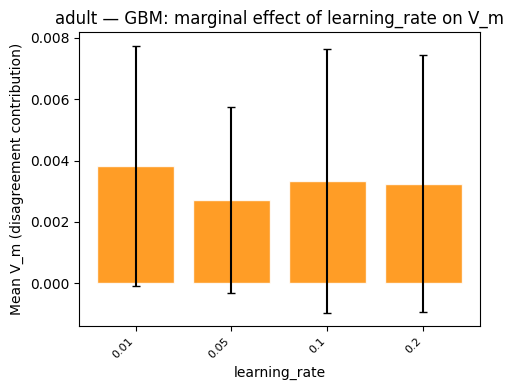

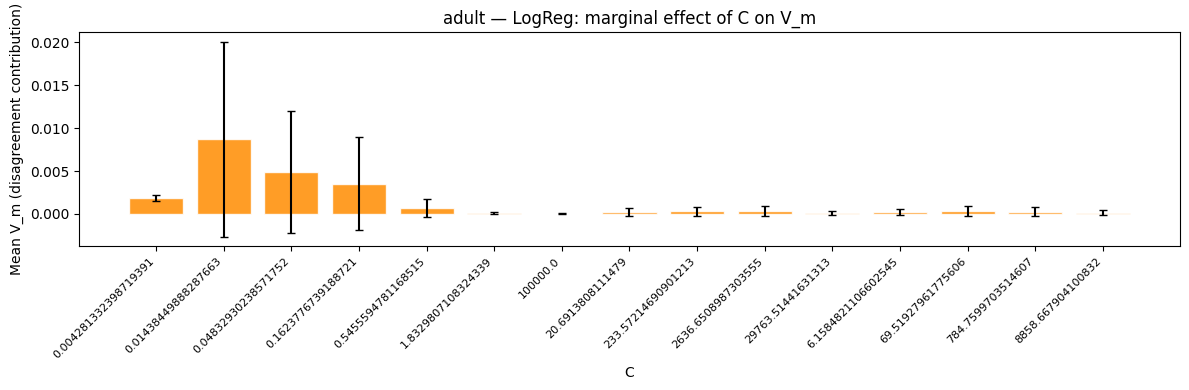

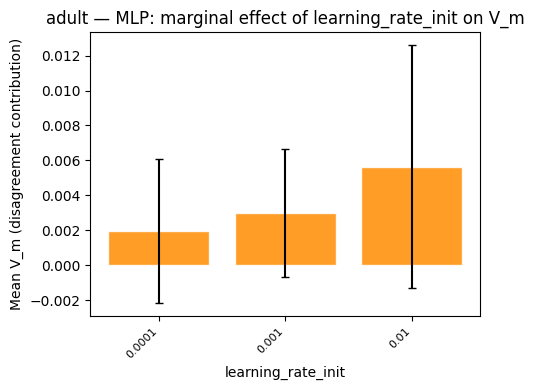

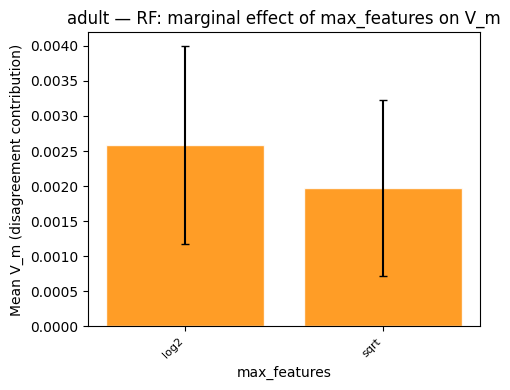

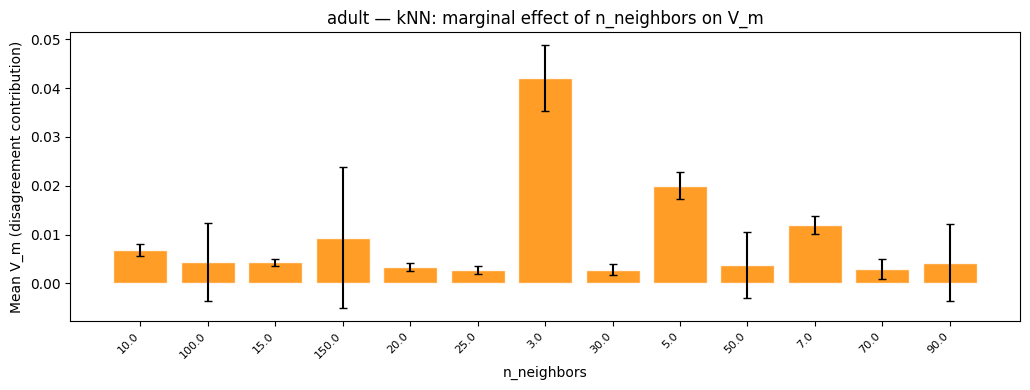

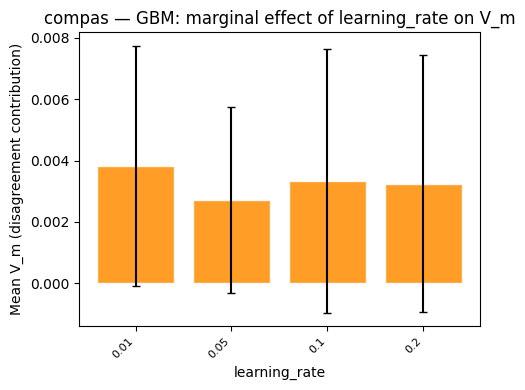

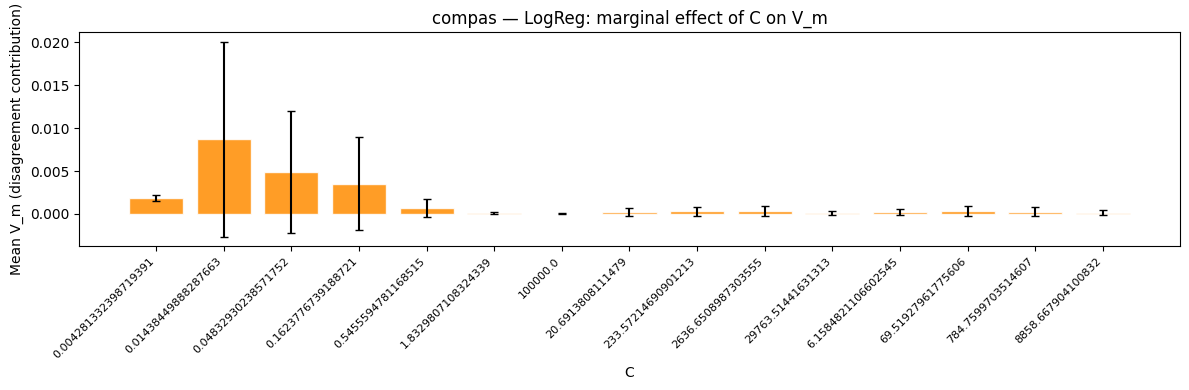

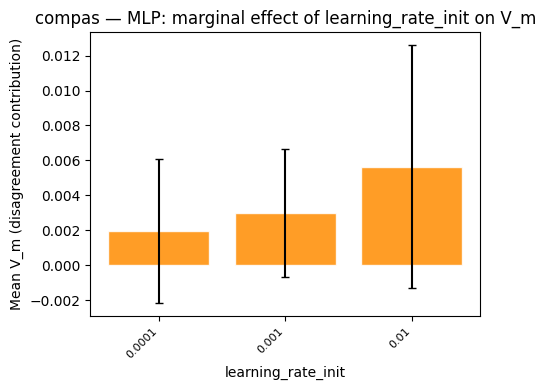

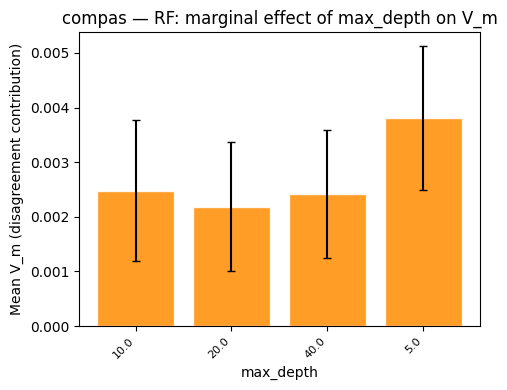

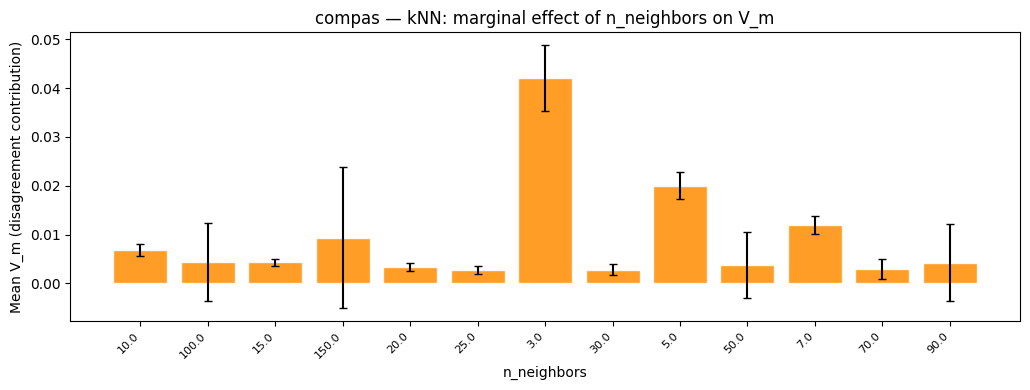

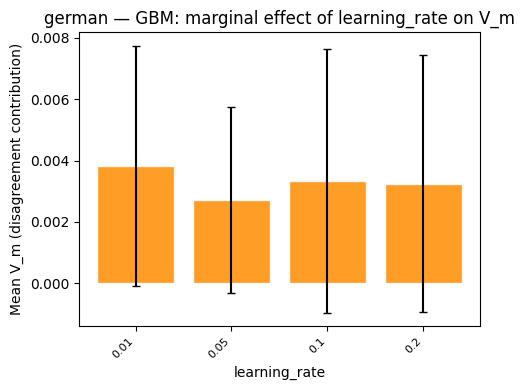

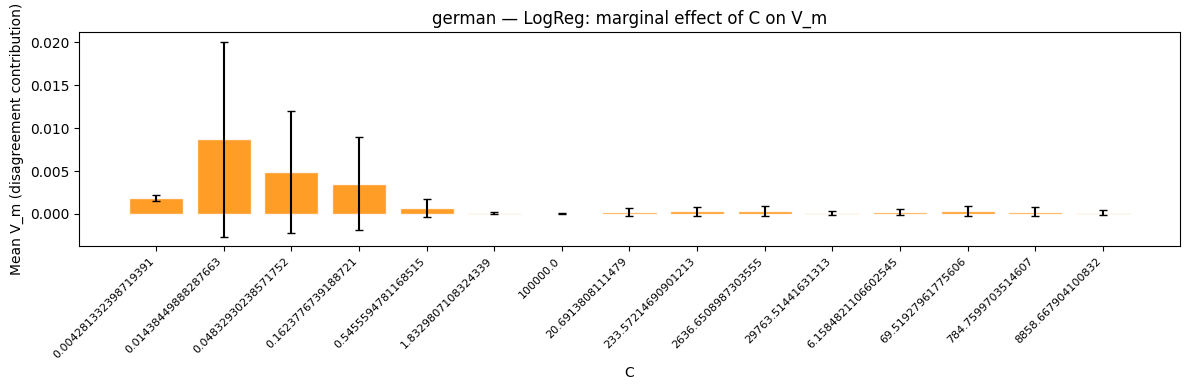

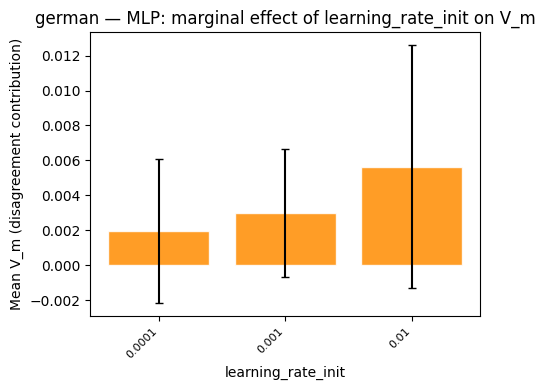

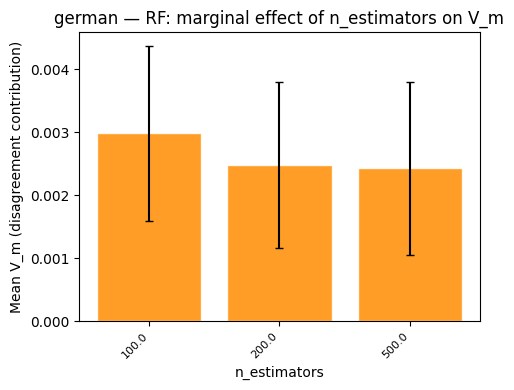

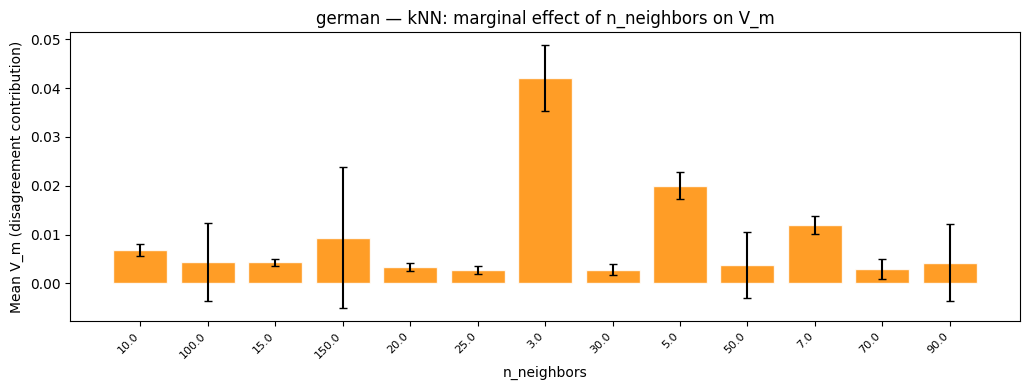

In [8]:
if not df_agg.empty and not df_Vm_all.empty:
    for (ds, fam), grp in df_agg.groupby(["dataset", "family"]):
        top1 = grp.iloc[0]
        hp_name = top1["hp_name"]
        hp_col = f"hp_{hp_name}"

        vm_sub = df_Vm_all[df_Vm_all["family"] == fam]
        if hp_col not in vm_sub.columns:
            print(f"Skipping {ds}/{fam}/{hp_name}: column not found")
            continue

        vm_sub = vm_sub.copy()
        vm_sub["_hp_key"] = vm_sub[hp_col].apply(make_hp_key)
        vm_sub = vm_sub[vm_sub["_hp_key"] != "nan"]
        if vm_sub.empty:
            continue

        marg = (
            vm_sub.groupby("_hp_key")["V_m"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        marg["std"] = marg["std"].fillna(0)
        marg = marg.sort_values("_hp_key")

        fig, ax = plt.subplots(figsize=(max(5, 0.8 * len(marg)), 4))
        x = range(len(marg))
        ax.bar(
            x,
            marg["mean"],
            yerr=marg["std"],
            capsize=3,
            color="darkorange",
            edgecolor="white",
            alpha=0.85,
        )
        ax.set_xticks(list(x))
        ax.set_xticklabels(marg["_hp_key"], rotation=45, ha="right", fontsize=8)
        ax.set_xlabel(hp_name)
        ax.set_ylabel("Mean V_m (disagreement contribution)")
        ax.set_title(f"{ds} — {fam}: marginal effect of {hp_name} on V_m")
        fig.tight_layout()
        safe_hp = hp_name.replace("/", "_").replace(" ", "_")
        fig.savefig(
            FIG_DIR / f"hp_marginal_effect_{ds}_{fam}_{safe_hp}.pdf",
            bbox_inches="tight",
        )
        plt.show()

## Diagnostic: K_actual and family sizes

Report per (dataset, family) the actual K used (min of K and n_candidates
in that family) and flag any truncation.

In [9]:
if not df_per_seed.empty:
    diag = (
        df_per_seed.groupby(["dataset", "family"])
        .agg(
            K_actual_min=("K_actual", "min"),
            K_actual_max=("K_actual", "max"),
            n_seeds=("seed", "nunique"),
        )
        .reset_index()
    )
    print("Per-family Rashomon size diagnostic:")
    print(diag.to_string(index=False))
    for _, row in diag.iterrows():
        if row["K_actual_min"] < K:
            print(
                f"  \u26a0 {row['dataset']}/{row['family']}: "
                f"K truncated to {row['K_actual_min']} (requested {K})"
            )

Per-family Rashomon size diagnostic:
dataset family  K_actual_min  K_actual_max  n_seeds
  adult    GBM            25            25       10
  adult LogReg            25            25       10
  adult    MLP            25            25       10
  adult     RF            25            25       10
  adult    kNN            25            25       10
 compas    GBM            25            25       10
 compas LogReg            25            25       10
 compas    MLP            25            25       10
 compas     RF            25            25       10
 compas    kNN            25            25       10
 german    GBM            25            25       10
 german LogReg            25            25       10
 german    MLP            25            25       10
 german     RF            25            25       10
 german    kNN            25            25       10


## Hyperparameter Diversity and Flexibility

Alternative to variance decomposition: measure how diverse the Rashomon set's hyperparameter configurations are.
1. **Diversity** — how many distinct HP values survive in the Rashomon set
2. **Entropy** — distribution spread of HP values (high entropy = flexible)
3. **Prediction differences** — mean prediction difference between models with different vs same HP values

In [10]:
from analysis.hyperparams import compute_hp_diversity, compute_hp_entropy, compute_prediction_difference_by_hp

for ds_name in DATASETS:
    print(f"\n{'='*60}")
    print(f"  HP Diversity Analysis: {ds_name}")
    print(f"{'='*60}")
    
    ds_dir = RESULTS_DIR / ds_name
    run_dirs = sorted(ds_dir.glob("seed=*"))
    
    all_div = []
    all_ent = []
    all_diff = []
    
    for run_dir in run_dirs:
        meta = load_meta(run_dir)
        meta = ensure_hp_columns(meta)
        P_test = load_P_test(run_dir)
        idx = select_rashomon_per_family_k_each(run_dir, K_each=K_EACH)
        meta_sel = meta.iloc[idx].reset_index(drop=True)
        P_sel = P_test[idx]
        
        div_df = compute_hp_diversity(meta_sel)
        ent_df = compute_hp_entropy(meta_sel)
        diff_df = compute_prediction_difference_by_hp(meta_sel, P_sel)
        
        div_df["run"] = run_dir.name
        ent_df["run"] = run_dir.name
        diff_df["run"] = run_dir.name
        
        all_div.append(div_df)
        all_ent.append(ent_df)
        all_diff.append(diff_df)
    
    if all_ent:
        ent_agg = pd.concat(all_ent).groupby(["family", "hp"]).agg(
            entropy_mean=("entropy", "mean"),
            entropy_std=("entropy", "std"),
            norm_entropy_mean=("normalized_entropy", "mean"),
            n_distinct_mean=("n_distinct", "mean"),
        ).reset_index()
        
        print("\n  Top flexible HPs (by normalized entropy, mean over seeds):")
        top_ent = ent_agg.sort_values("norm_entropy_mean", ascending=False).head(15)
        for _, row in top_ent.iterrows():
            print(f"    {row['family']:>10s} / {row['hp']:<20s}: "
                  f"norm_H={row['norm_entropy_mean']:.3f}, "
                  f"n_distinct={row['n_distinct_mean']:.1f}")
    
    if all_diff:
        diff_agg = pd.concat(all_diff).groupby(["family", "hp"]).agg(
            diff_different_mean=("mean_diff_different_hp", "mean"),
            diff_same_mean=("mean_diff_same_hp", "mean"),
        ).reset_index()
        diff_agg["diff_ratio"] = diff_agg["diff_different_mean"] / (diff_agg["diff_same_mean"] + 1e-12)
        
        print("\n  Top prediction-difference HPs (different vs same HP value):")
        top_diff = diff_agg.sort_values("diff_ratio", ascending=False).head(15)
        for _, row in top_diff.iterrows():
            print(f"    {row['family']:>10s} / {row['hp']:<20s}: "
                  f"diff_ratio={row['diff_ratio']:.2f}, "
                  f"diff_different={row['diff_different_mean']:.6f}")


  HP Diversity Analysis: compas

  Top flexible HPs (by normalized entropy, mean over seeds):
           kNN / p                   : norm_H=0.996, n_distinct=2.0
           kNN / n_neighbors         : norm_H=0.990, n_distinct=12.7
            RF / n_estimators        : norm_H=0.983, n_distinct=3.0
           MLP / alpha               : norm_H=0.974, n_distinct=4.0
           GBM / subsample           : norm_H=0.966, n_distinct=3.0
        LogReg / l1_ratio            : norm_H=0.965, n_distinct=5.0
            RF / min_samples_split   : norm_H=0.965, n_distinct=3.0
        LogReg / C                   : norm_H=0.965, n_distinct=11.0
           GBM / n_estimators        : norm_H=0.958, n_distinct=3.0
           MLP / hidden_layer_sizes  : norm_H=0.957, n_distinct=5.0
           MLP / activation          : norm_H=0.930, n_distinct=2.0
           GBM / max_depth           : norm_H=0.929, n_distinct=3.9
            RF / max_features        : norm_H=0.928, n_distinct=2.0
            RF / mi

## Summary

In [11]:
if not df_agg.empty:
    print("Top-3 most important HPs per (dataset, family):\n")
    for (ds, fam), grp in df_agg.groupby(["dataset", "family"]):
        top3 = grp.head(3)
        items = ", ".join(
            f"{r.hp_name} ({r.mean_importance:.3f} \u00b1 {r.std_importance:.3f})"
            for _, r in top3.iterrows()
        )
        print(f"  {ds} | {fam}: {items}")

Top-3 most important HPs per (dataset, family):

  adult | GBM: learning_rate (0.247 ± 0.087), max_depth (0.117 ± 0.091), n_estimators (0.113 ± 0.097)
  adult | LogReg: C (0.921 ± 0.070), l1_ratio (0.112 ± 0.059)
  adult | MLP: learning_rate_init (0.513 ± 0.180), hidden_layer_sizes (0.159 ± 0.116), alpha (0.138 ± 0.142)
  adult | RF: max_features (0.669 ± 0.111), max_depth (0.113 ± 0.093), min_samples_leaf (0.107 ± 0.053)
  adult | kNN: n_neighbors (0.868 ± 0.040), weights (0.113 ± 0.042), p (0.021 ± 0.019)
  compas | GBM: learning_rate (0.151 ± 0.125), max_depth (0.141 ± 0.061), n_estimators (0.128 ± 0.096)
  compas | LogReg: C (0.862 ± 0.121), l1_ratio (0.107 ± 0.039)
  compas | MLP: learning_rate_init (0.266 ± 0.122), hidden_layer_sizes (0.181 ± 0.078), alpha (0.159 ± 0.130)
  compas | RF: max_depth (0.333 ± 0.212), min_samples_leaf (0.113 ± 0.107), min_samples_split (0.108 ± 0.101)
  compas | kNN: n_neighbors (0.733 ± 0.272), weights (0.627 ± 0.271), p (0.025 ± 0.031)
  german | GB